# Huellas y rastros

Por: Daning Montaño

# Librerías

In [1]:
library(ggplot2)
library(dplyr)
library(lubridate)
library(bslib)
source("Functions/plot_themes.R")
library(stringr)
library(plotly)
library(tidyr)
library(htmlwidgets)
library(dygraphs)
library(xts)
library(tidyverse)
library(googleVis)
library(scales)
library(tidytext)
library(igraph)
library(ggraph)
library(wordcloud)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Attaching package: ‘bslib’

The following object is masked from ‘package:utils’:

    page


Attaching package: ‘plotly’

The following object is masked from ‘package:ggplot2’:

    last_plot

The following object is masked from ‘package:stats’:

    filter

The following object is masked from ‘package:graphics’:

    layout



Warning message:
package ‘htmlwidgets’ was built under R version 4.4.3 
Warning message:
package ‘dygraphs’ was built under R version 4.4.3 


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#                                                                             #
# Code in packages is not affected. It's protected by R's

Warning messages:
1: package ‘xts’ was built under R version 4.4.3 
2: package ‘zoo’ was built under R version 4.4.3 


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ readr   2.2.0
✔ purrr   1.0.2     ✔ tibble  3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ plotly::filter() masks dplyr::filter(), stats::filter()
✖ xts::first()     masks dplyr::first()
✖ dplyr::lag()     masks stats::lag()
✖ xts::last()      masks dplyr::last()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


...

Warning message:
package ‘tidytext’ was built under R version 4.4.3 



Attaching package: ‘igraph’

The following objects are masked from ‘package:purrr’:

    compose, simplify

The following object is masked from ‘package:tibble’:

    as_data_frame

The following object is masked from ‘package:tidyr’:

    crossing

The following object is masked from ‘package:plotly’:

    groups

The following objects are masked from ‘package:lubridate’:

    %--%, union

The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union



Warning message:
package ‘igraph’ was built under R version 4.4.3 
Warning message:
package ‘ggraph’ was built under R version 4.4.3 


Loading required package: RColorBrewer


Warning message:
package ‘wordcloud’ was built under R version 4.4.3 


# Carga de datos

In [2]:
huellas_rastros_0 = read.csv("../Data/Evidencias_jaguar.csv")
huellas_rastros_0$Fecha = as.Date(huellas_rastros_0$Fecha, format = "%Y-%m-%d")
head(huellas_rastros_0)

  X      X_id                               X_uuid           X__version__
1 0 450748369 00ac5a0d-8a8d-48d7-a436-e2f83c7bf293 vAQqv5sLSAx3BQXYG2habd
2 1 453395064 2aa52c14-aaa1-4819-aba1-e2e33adb17e0 vAQqv5sLSAx3BQXYG2habd
3 2 456705327 64879b55-bb25-4ee8-9cb4-c6c17e81ee7f vAQqv5sLSAx3BQXYG2habd
4 3 458421837 ef0202cb-530c-4042-b3da-7e608cbb624a vAQqv5sLSAx3BQXYG2habd
5 4 458759506 42dcebc7-611d-4441-8deb-f48983f5cdfb vAQqv5sLSAx3BQXYG2habd
6 5 459857647 8d9e0dc2-e8f0-4b25-9d57-03b91dcbc018 vAQqv5sLSAx3BQXYG2habd
    X_submission_time X_validation_status  timestamp           X_submitted_by
1 2025-03-11T16:42:29            Approved 1756389003     conservacion_napurak
2 2025-03-18T14:21:56            Approved 1760973875  conservacion_shuinmamus
3 2025-03-26T18:05:53            Approved 1749759267 conservacion_sharamentsa
4 2025-04-01T14:22:07            Approved 1744039210 conservacion_sharamentsa
5 2025-04-02T14:37:43            Approved 1744040169 conservacion_sharamentsa
6 2025-04-05T2

# Análisis de datos

In [3]:
str(huellas_rastros_0)

'data.frame':	87 obs. of  27 variables:
 $ X                  : int  0 1 2 3 4 5 6 7 8 9 ...
 $ X_id               : int  450748369 453395064 456705327 458421837 458759506 459857647 460022815 460281183 460407515 460857939 ...
 $ X_uuid             : chr  "00ac5a0d-8a8d-48d7-a436-e2f83c7bf293" "2aa52c14-aaa1-4819-aba1-e2e33adb17e0" "64879b55-bb25-4ee8-9cb4-c6c17e81ee7f" "ef0202cb-530c-4042-b3da-7e608cbb624a" ...
 $ X__version__       : chr  "vAQqv5sLSAx3BQXYG2habd" "vAQqv5sLSAx3BQXYG2habd" "vAQqv5sLSAx3BQXYG2habd" "vAQqv5sLSAx3BQXYG2habd" ...
 $ X_submission_time  : chr  "2025-03-11T16:42:29" "2025-03-18T14:21:56" "2025-03-26T18:05:53" "2025-04-01T14:22:07" ...
 $ X_validation_status: chr  "Approved" "Approved" "Approved" "Approved" ...
 $ timestamp          : int  1756389003 1760973875 1749759267 1744039210 1744040169 1744657660 1744657658 1744040224 1744217147 1744217206 ...
 $ X_submitted_by     : chr  "conservacion_napurak" "conservacion_shuinmamus" "conservacion_sharamentsa" "conse

In [4]:
huellas_rastros_0 <- huellas_rastros_0 %>%
  mutate(
    Id_taxonomica = ifelse(Nivel_taxonomico == "" | is.na(Nivel_taxonomico),
                           "No identificada",
                           "Identificada")
  )

## Trabajo comunidades

In [5]:
conteo_actividades <- huellas_rastros_0 %>%
  # Filtramos desde el 1 de diciembre de 2024 en adelante
  filter(Fecha >= as.Date("2025-01-01")) %>%
  group_by(Comunidad,Id_taxonomica ) %>%
  summarise(Total_registros = n()) %>%
  arrange(desc(Comunidad))

# Visualizar resultado
conteo_actividades

`summarise()` has grouped output by 'Comunidad'. You can override using the
`.groups` argument.


# A tibble: 9 × 3
# Groups:   Comunidad [5]
  Comunidad    Id_taxonomica   Total_registros
  <chr>        <chr>                     <int>
1 Wayusentsa   Identificada                  5
2 Wayusentsa   No identificada              44
3 Shuinmamus   Identificada                  9
4 Shuinmamus   No identificada               2
5 Sharamentsa  Identificada                  3
6 Sharamentsa  No identificada               9
7 Napurak      Identificada                  9
8 Napurak      No identificada               3
9 Hotel Kapawi No identificada               3

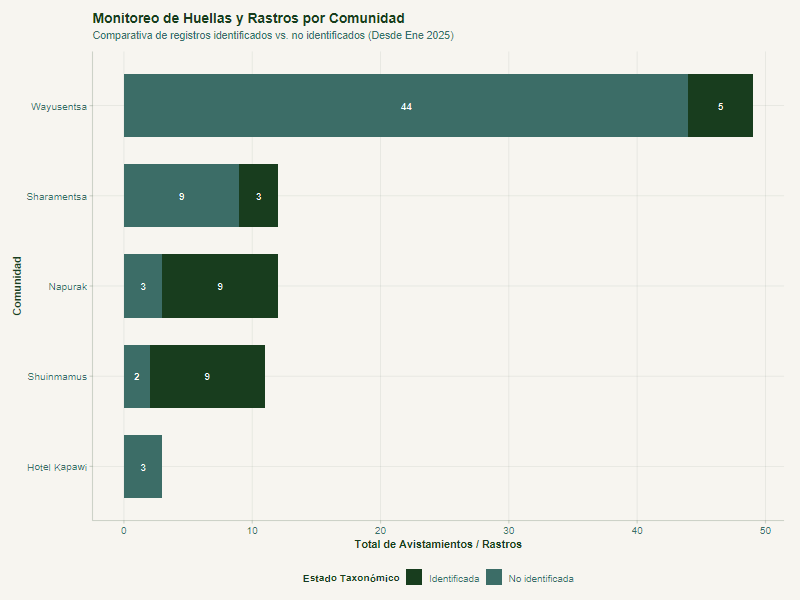

In [6]:
conteo_grafico <- conteo_actividades %>%
  group_by(Comunidad) %>%
  mutate(Porcentaje = Total_registros / sum(Total_registros) * 100) %>%
  ungroup()

ggplot(conteo_grafico, aes(x = reorder(Comunidad, Total_registros), y = Total_registros, fill = Id_taxonomica)) +
  # Barras apiladas
  geom_col(position = "stack", width = 0.7) +
  
  # Añadir etiquetas con el número total dentro de las barras
  geom_text(aes(label = Total_registros), 
            position = position_stack(vjust = 0.5), 
            color = "white", 
            fontface = "bold",
            size = 3.5) +
  
  # Colores institucionales (Verde Hoja para Identificadas, Rio para No identificadas)
  scale_fill_manual(values = c("Identificada" = PAL$hoja, "No identificada" = PAL$rio)) +
  
  # Girar coordenadas para que los nombres de las comunidades se lean bien
  coord_flip() +
  
  labs(
    title = "Monitoreo de Huellas y Rastros por Comunidad",
    subtitle = "Comparativa de registros identificados vs. no identificados (Desde Ene 2025)",
    x = "Comunidad",
    y = "Total de Avistamientos / Rastros",
    fill = "Estado Taxonómico"
  ) +
  
  theme_pachamama() +
  theme(
    legend.position = "bottom",
    text = element_text(family = "sans")
  )

## Registros por año

In [7]:
unique(huellas_rastros_0$Nombre_cientifico)

[1] ""                             "Panthera onca"               
[3] "Puma concolor"                "Leopardus"                   
[5] "Leopardus pardalis"           "Canis familiaris"            
[7] "En el horilla de rio pastaza"

In [13]:
serie_anual_Registro<- huellas_rastros_0 %>%
  mutate(Year = floor_date(as.Date(Fecha), "year")) %>%
  filter(Nombre_cientifico== "Panthera onca")%>%
  group_by(Year,Comunidad ) %>%
    summarise(Total_registros = n(), .groups = "drop") 
  serie_anual_Registro

# A tibble: 4 × 3
  Year       Comunidad   Total_registros
  <date>     <chr>                 <int>
1 2025-01-01 Napurak                   4
2 2025-01-01 Sharamentsa               2
3 2025-01-01 Shuinmamus                3
4 2025-01-01 Wayusentsa                4

In [14]:
serie_anual_Registro

# A tibble: 4 × 3
  Year       Comunidad   Total_registros
  <date>     <chr>                 <int>
1 2025-01-01 Napurak                   4
2 2025-01-01 Sharamentsa               2
3 2025-01-01 Shuinmamus                3
4 2025-01-01 Wayusentsa                4

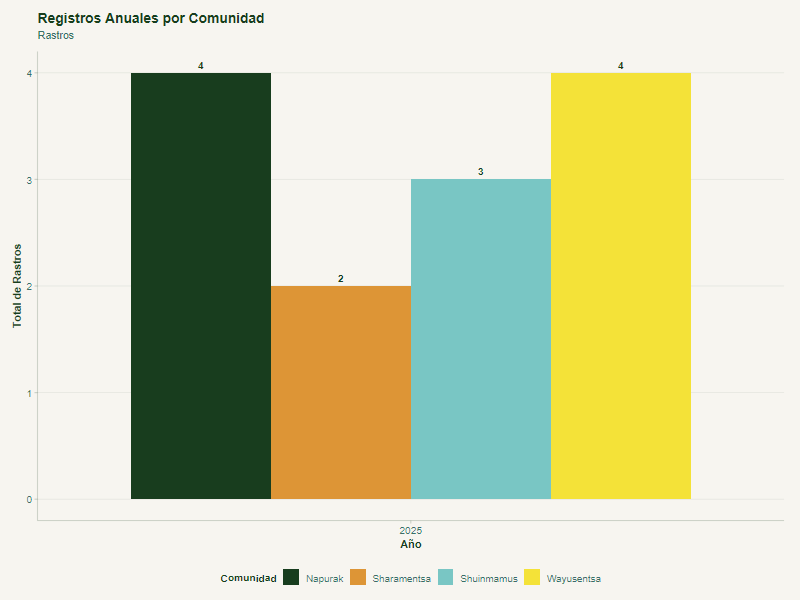

In [17]:

# Aseguramos que el año se trate como una categoría (factor) para que el eje X sea limpio
serie_anual_alimentaria <- serie_anual_Registro %>%
  mutate(Anio_Label = format(Year, "%Y"))

ggplot(serie_anual_alimentaria, aes(x = Anio_Label, y = Total_registros, fill = Comunidad)) +
  # position = "dodge" crea las barras una al lado de la otra
  geom_col(position = position_dodge(width = 0.9)) +
  
  # Añadir el total sobre cada barra
  geom_text(aes(label = Total_registros), 
            position = position_dodge(width = 0.9), 
            vjust = -0.5,      # Ajuste vertical para que esté arriba de la barra
            size = 3.5, 
            fontface = "bold",
            color = PAL$hoja) +
  
  # Colores institucionales
  scale_fill_manual(values = PAL_CUAL) +
  
  labs(
    title = "Registros Anuales por Comunidad",
    subtitle = "Rastros",
    x = "Año",
    y = "Total de Rastros",
    fill = "Comunidad"
  ) +
  
  # Tu tema de la Fundación
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(), # Limpiamos el eje X para que se vea más moderno
    text = element_text(family = "sans")
  )

## Descripción de Entorno del registro

In [19]:
huellas_rastros_0$Entorno

 [1] "En el camino vía napurak a awampuik"                                                            
 [2] "En la orilla del río"                                                                           
 [3] "Lindero de Suwa-Sharamentsa, se evidencio hueso y pelajes del animal que se alimento el jaguar."
 [4] "Huella de jaguar"                                                                               
 [5] "Se encontró la evidencia en el río tsuatentsa."                                                 
 [6] "Sendero kunkuk, cima de loma"                                                                   
 [7] "Sendero hotel-lobo."                                                                            
 [8] "La raspada de jaguar"                                                                           
 [9] "Camino Rafael Entsakua"                                                                         
[10] "Bosque secundario"                                                 

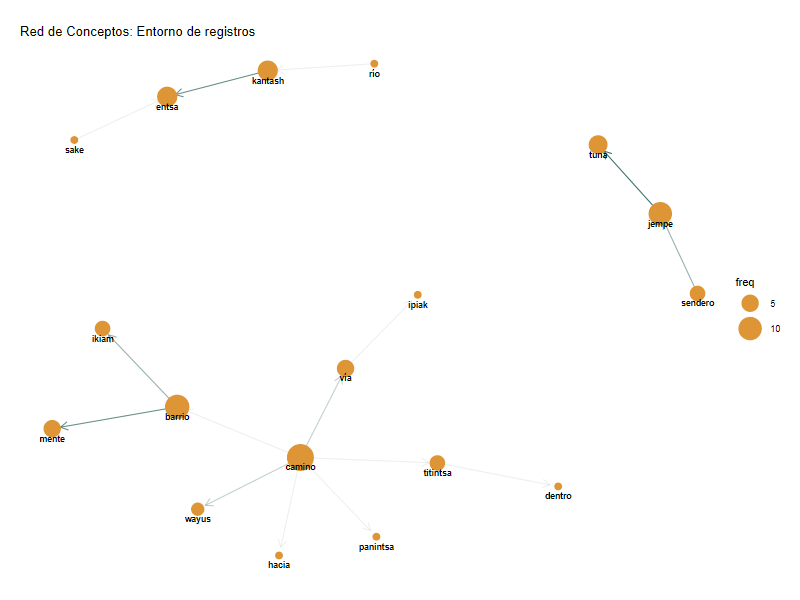

In [21]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- huellas_rastros_0 %>%
  filter(!is.na(Entorno)) %>%
  mutate(texto = str_to_lower(Entorno) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")


# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos: Entorno de registros",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))